In [2]:
import os, numpy as np
good_dir = "/home/xw0418/cse237A/SittingPostureDetection/data/dataset/good_posture"
bad_dir = "/home/xw0418/cse237A/SittingPostureDetection/data/dataset/bad_posture"
good_files = os.listdir(good_dir)
bad_files = os.listdir(bad_dir)


In [3]:
np.load(os.path.join(good_dir, good_files[0]))

array([[ 8.85076218e+01,  1.49211013e+00,  2.84275711e-02],
       [ 8.75246124e+01,  2.24249339e+00, -1.04831254e+00],
       [ 8.73053360e+01,  2.52816796e+00, -9.32696700e-01],
       [ 8.68823700e+01,  3.11298084e+00, -1.70352891e-01],
       [ 8.72813950e+01,  2.61578655e+00, -7.40790486e-01],
       [ 8.68297119e+01,  3.10191655e+00, -6.55144513e-01],
       [ 8.66602783e+01,  3.14559269e+00, -1.12239528e+00],
       [ 8.73524170e+01,  2.53721070e+00, -7.56666780e-01],
       [ 8.69355392e+01,  3.06306958e+00,  9.22635347e-02],
       [ 8.72881012e+01,  2.66371608e+00, -5.09073794e-01]])

In [4]:
good_matrices = [ np.load(os.path.join(good_dir, gf))  for gf in good_files]
good_matrices = np.vstack(good_matrices)
bad_matrices = [ np.load(os.path.join(bad_dir, bf))  for bf in bad_files]
bad_matrices = np.vstack(bad_matrices)

In [5]:
good_matrices.shape, bad_matrices.shape

((150, 3), (200, 3))

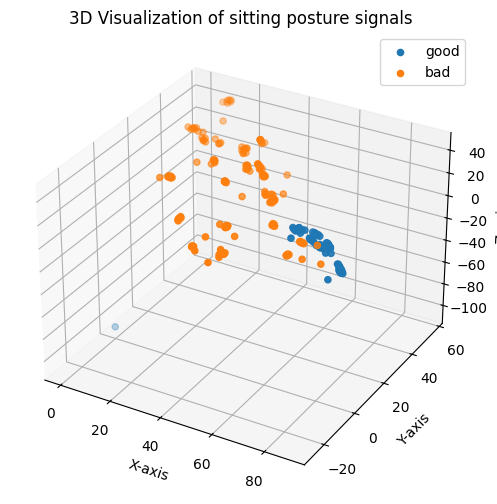

In [6]:
import matplotlib.pyplot as plt

# Generate some example 10x3 arrays
num_arrays = 5  # Number of 10x3 arrays

# Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot each 10x3 array in 3D space
x,y,z = good_matrices[:,0], good_matrices[:,1], good_matrices[:,2]
ax.scatter(x, y, z, label=f'good')

x,y,z = bad_matrices[:,0], bad_matrices[:,1], bad_matrices[:,2]
ax.scatter(x, y, z, label=f'bad')

# Labels and legend
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
ax.set_title("3D Visualization of sitting posture signals")
ax.legend()

plt.show()


In [7]:
good_matrices.mean(axis=0), bad_matrices.mean(axis=0)

(array([78.59262705,  6.72856517,  6.25858514]),
 array([42.79565603, 11.62033102, 32.61703638]))

In [8]:
# cross validation
import numpy as np

from ML_utils import kfold_split

In [9]:
# method 1: thresholding
all_accu = []   
threshold = (good_matrices.mean(axis=0)+bad_matrices.mean(axis=0))/2
for X_train, X_test, y_train, y_test in kfold_split(good_matrices, bad_matrices):
    y_out = (X_test[:,0]>threshold[0]).astype(int) + (X_test[:,1]<threshold[1]).astype(int) + (X_test[:,2]<threshold[2]) .astype(int)
    y_pred = (y_out >= 2).astype(int)
    # y_pred = (X_test > threshold).all(axis=1)
    accuracy = (y_pred == y_test).mean()
    print(f"Accuracy: {accuracy:.2f}")
    all_accu.append(accuracy)
print(f"Average accuracy: {np.mean(all_accu):.2f}")
print(f"Standard deviation: {np.std(all_accu):.2f}")

Accuracy: 0.80
Accuracy: 0.94
Accuracy: 0.91
Accuracy: 0.97
Accuracy: 0.91
Accuracy: 0.97
Accuracy: 0.91
Accuracy: 0.89
Accuracy: 0.86
Accuracy: 0.94
Average accuracy: 0.91
Standard deviation: 0.05


In [12]:
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
def evaluate_knn_rf(good_matrices, bad_matrices, n_splits=10):
    all_accu_knn = []
    all_accu_rf = []
    
    for X_train, X_test, y_train, y_test in kfold_split(good_matrices, bad_matrices, n_splits):
        
        # K-Nearest Neighbors
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train, y_train)
        y_pred_knn = knn.predict(X_test)
        accuracy_knn = (y_pred_knn == y_test).mean()
        all_accu_knn.append(accuracy_knn)
        
        # Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        accuracy_rf = (y_pred_rf == y_test).mean()
        all_accu_rf.append(accuracy_rf)
    
    print(f"KNN - Average accuracy: {np.mean(all_accu_knn):.2f}")
    print(f"KNN - Standard deviation: {np.std(all_accu_knn):.2f}")
    print(f"Random Forest - Average accuracy: {np.mean(all_accu_rf):.2f}")
    print(f"Random Forest - Standard deviation: {np.std(all_accu_rf):.2f}")
    return knn, rf
knn, rf = evaluate_knn_rf(good_matrices, bad_matrices, n_splits=10)

KNN - Average accuracy: 0.99
KNN - Standard deviation: 0.01
Random Forest - Average accuracy: 0.99
Random Forest - Standard deviation: 0.01


In [23]:
knn.predict(np.array([[1,2,3]]))

array([0.])

In [22]:
knn.predict_proba(np.array([0.3, 0.4,3]).reshape(1,-1)), 

(array([[1., 0.]]),)

In [11]:
import numpy as np

matrix = np.array([[1, 6, 3], [7, 2, 9]])

# Get boolean array
bool_mask = matrix > 5
print(bool_mask)


[[False  True False]
 [ True False  True]]
